# Universal Data Analyzer
### A complete analysis notebook for any dataset

**Supported Formats:** CSV, Excel (.xlsx/.xls), JSON, TSV

Simply set your file path below and run all cells to get a full analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

print("Universal Data Analyzer")
print("=======================")
print(f"Session started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Universal Data Analyzer
Session started: 2026-05-05 17:17:48


## Step 1 : Load Your Data
Change the `FILE_PATH` below to point to your data file.

In [2]:
# ============================================
# SET YOUR FILE PATH HERE
# ============================================
FILE_PATH = "Trans.csv"
# ============================================

import os
ext = os.path.splitext(FILE_PATH)[1].lower()

if ext == ".csv":
    df = pd.read_csv(FILE_PATH)
elif ext in [".xlsx", ".xls"]:
    df = pd.read_excel(FILE_PATH)
elif ext == ".json":
    df = pd.read_json(FILE_PATH)
elif ext == ".tsv":
    df = pd.read_csv(FILE_PATH, sep="\t")
else:
    raise ValueError(f"Unsupported file format: {ext}")

print(f"Data loaded successfully from: {FILE_PATH}")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Loaded at: {datetime.now().strftime('%H:%M:%S')}")

Data loaded successfully from: Trans.csv
Shape: 1000 rows x 12 columns
Loaded at: 17:17:48


In [3]:
df

,Transaction_ID,Transaction_Amount,Transaction_Volume,Average_Transaction_Amount,Frequency_of_Transactions,Time_Since_Last_Transaction,Day_of_Week,Time_of_Day,Age,Gender,Income,Account_Type
0,TX0,1024.835708,3,997.234714,12,29,Friday,06:00,36,Male,1436074,Savings
1,TX1,1013.952065,4,1020.210306,7,22,Friday,01:00,41,Female,627069,Savings
2,TX2,970.956093,1,989.496604,5,12,Tuesday,21:00,61,Male,786232,Savings
3,TX3,1040.822254,2,969.522480,16,28,Sunday,14:00,61,Male,619030,Savings
4,TX4,998.777241,1,1007.111026,7,7,Friday,08:00,56,Female,649457,Savings
...,...,...,...,...,...,...,...,...,...,...,...,...
995,TX995,901.138758,3,976.363229,17,19,Monday,05:00,46,Female,424746,Savings
996,TX996,928.962516,4,1028.292292,10,25,Wednesday,09:00,58,Female,908278,Current
997,TX997,950.921600,2,1022.823424,13,28,Friday,02:00,58,Female,1353498,Current
998,TX998,933.291962,4,994.325450,10,8,Tuesday,04:00,58,Female,359072,Savings


In [4]:
df.shape

(1000, 12)

## Display_Head & Tail

In [5]:
First_Rows = df.head()
First_Rows

,Transaction_ID,Transaction_Amount,Transaction_Volume,Average_Transaction_Amount,Frequency_of_Transactions,Time_Since_Last_Transaction,Day_of_Week,Time_of_Day,Age,Gender,Income,Account_Type
0,TX0,1024.835708,3,997.234714,12,29,Friday,06:00,36,Male,1436074,Savings
1,TX1,1013.952065,4,1020.210306,7,22,Friday,01:00,41,Female,627069,Savings
2,TX2,970.956093,1,989.496604,5,12,Tuesday,21:00,61,Male,786232,Savings
3,TX3,1040.822254,2,969.522480,16,28,Sunday,14:00,61,Male,619030,Savings
4,TX4,998.777241,1,1007.111026,7,7,Friday,08:00,56,Female,649457,Savings


In [6]:
Last_Rows = df.tail()
Last_Rows

,Transaction_ID,Transaction_Amount,Transaction_Volume,Average_Transaction_Amount,Frequency_of_Transactions,Time_Since_Last_Transaction,Day_of_Week,Time_of_Day,Age,Gender,Income,Account_Type
995,TX995,901.138758,3,976.363229,17,19,Monday,05:00,46,Female,424746,Savings
996,TX996,928.962516,4,1028.292292,10,25,Wednesday,09:00,58,Female,908278,Current
997,TX997,950.921600,2,1022.823424,13,28,Friday,02:00,58,Female,1353498,Current
998,TX998,933.291962,4,994.325450,10,8,Tuesday,04:00,58,Female,359072,Savings
999,TX999,968.289340,3,979.078420,18,10,Sunday,10:00,31,Female,1101680,Current


## Data Info & Types

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Transaction_ID               1000 non-null   object 
 1   Transaction_Amount           1000 non-null   float64
 2   Transaction_Volume           1000 non-null   int64  
 3   Average_Transaction_Amount   1000 non-null   float64
 4   Frequency_of_Transactions    1000 non-null   int64  
 5   Time_Since_Last_Transaction  1000 non-null   int64  
 6   Day_of_Week                  1000 non-null   object 
 7   Time_of_Day                  1000 non-null   object 
 8   Age                          1000 non-null   int64  
 9   Gender                       1000 non-null   object 
 10  Income                       1000 non-null   int64  
 11  Account_Type                 1000 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 93.9+ KB


In [8]:
print("Column Data Types:")
print("==================")
df.dtypes

Column Data Types:


Transaction_ID                  object
Transaction_Amount             float64
Transaction_Volume               int64
Average_Transaction_Amount     float64
Frequency_of_Transactions        int64
Time_Since_Last_Transaction      int64
Day_of_Week                     object
Time_of_Day                     object
Age                              int64
Gender                          object
Income                           int64
Account_Type                    object
dtype: object

In [9]:
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"Total Cells: {df.shape[0] * df.shape[1]}")
print(f"Numeric Columns: {len(df.select_dtypes(include='number').columns)}")
print(f"Categorical Columns: {len(df.select_dtypes(include='object').columns)}")
print(f"DateTime Columns: {len(df.select_dtypes(include='datetime').columns)}")

Memory Usage: 322.47 KB
Total Cells: 12000
Numeric Columns: 7
Categorical Columns: 5
DateTime Columns: 0


# Data Cleaning & EDA

In [10]:
Null_Vals = df.isnull().sum()
Null_Vals

Transaction_ID                 0
Transaction_Amount             0
Transaction_Volume             0
Average_Transaction_Amount     0
Frequency_of_Transactions      0
Time_Since_Last_Transaction    0
Day_of_Week                    0
Time_of_Day                    0
Age                            0
Gender                         0
Income                         0
Account_Type                   0
dtype: int64

In [11]:
Null_Pct = (df.isnull().sum() / len(df) * 100).round(2)
null_summary = pd.DataFrame({"Missing Count": Null_Vals, "Missing %": Null_Pct})
null_summary = null_summary[null_summary["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print("Columns with Missing Values:")
null_summary

Columns with Missing Values:


,Missing Count,Missing %


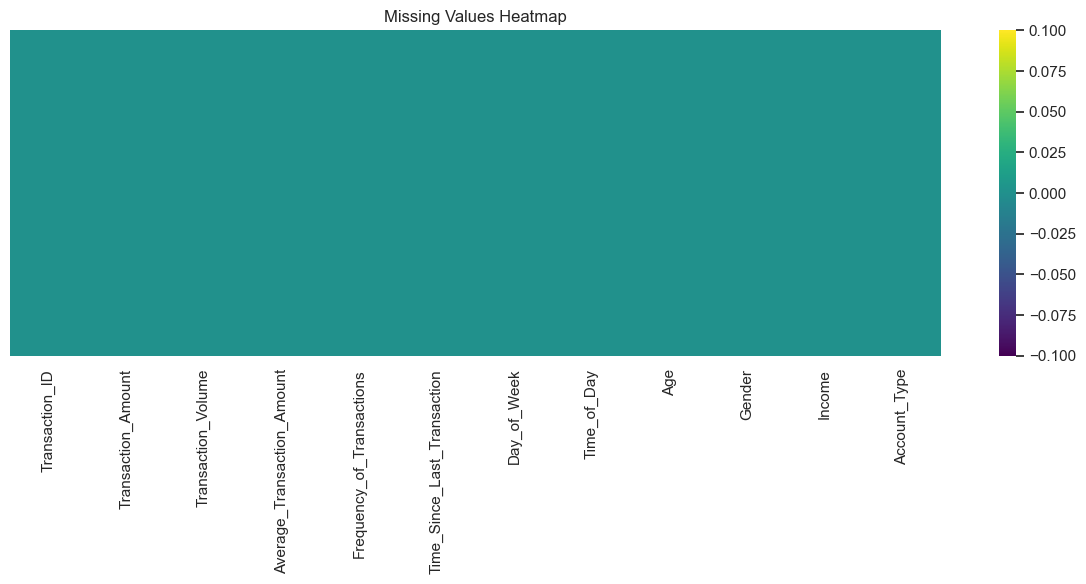

In [12]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

In [13]:
before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]
print(f"Rows before: {before}")
print(f"Rows after removing duplicates: {after}")
print(f"Duplicates removed: {before - after}")

Rows before: 1000
Rows after removing duplicates: 1000
Duplicates removed: 0


In [14]:
import warnings

# Auto-detect and convert date-like columns
for col in df.select_dtypes(include="object").columns:
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=UserWarning)
            converted = pd.to_datetime(df[col])
            df[col] = converted
            print(f"Converted '{col}' to datetime")
    except (ValueError, TypeError):
        pass
print("Date detection complete.")

Converted 'Time_of_Day' to datetime
Date detection complete.


In [15]:
df.describe()

,Transaction_Amount,Transaction_Volume,Average_Transaction_Amount,Frequency_of_Transactions,Time_Since_Last_Transaction,Time_of_Day,Age,Income
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.000000,1.000000e+03
mean,1038.122511,2.498000,1000.682506,12.078000,15.341000,2026-05-05 11:47:45.600000256,40.641000,8.948238e+05
min,849.024392,1.000000,939.081423,5.000000,1.000000,2026-05-05 00:00:00,18.000000,3.001590e+05
25%,966.028796,1.000000,986.800556,8.000000,8.000000,2026-05-05 05:45:00,29.000000,5.917308e+05
50%,1002.118678,3.000000,1000.501902,12.000000,16.000000,2026-05-05 12:00:00,41.000000,8.876645e+05
75%,1033.143657,3.000000,1015.155595,16.000000,22.000000,2026-05-05 18:00:00,53.000000,1.178102e+06
max,3227.459108,4.000000,1073.154036,19.000000,29.000000,2026-05-05 23:00:00,64.000000,1.499670e+06
std,283.580055,1.115006,20.632334,4.245225,8.361258,NaN,13.819953,3.453562e+05


In [16]:
cat_desc = df.describe(include="object")
if not cat_desc.empty:
    print("Categorical Summary:")
    display(cat_desc)
else:
    print("No categorical columns found.")

Categorical Summary:


,Transaction_ID,Day_of_Week,Gender,Account_Type
count,1000,1000,1000,1000
unique,1000,7,2,2
top,TX0,Tuesday,Female,Current
freq,1,157,517,516


## Column Analysis

In [17]:
col_summary = pd.DataFrame({
    "Type": df.dtypes,
    "Unique": df.nunique(),
    "Nulls": df.isnull().sum(),
    "Null %": (df.isnull().sum() / len(df) * 100).round(2),
    "Sample": [df[col].dropna().iloc[0] if not df[col].dropna().empty else None for col in df.columns]
})
col_summary

,Type,Unique,Nulls,Null %,Sample
Transaction_ID,object,1000,0,0.0,TX0
Transaction_Amount,float64,1000,0,0.0,1024.835708
Transaction_Volume,int64,4,0,0.0,3
Average_Transaction_Amount,float64,1000,0,0.0,997.234714
Frequency_of_Transactions,int64,15,0,0.0,12
Time_Since_Last_Transaction,int64,29,0,0.0,29
Day_of_Week,object,7,0,0.0,Friday
Time_of_Day,datetime64[ns],24,0,0.0,2026-05-05 06:00:00
Age,int64,47,0,0.0,36
Gender,object,2,0,0.0,Male


In [18]:
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    print(f"\n--- {col} (Top 10) ---")
    print(df[col].value_counts().head(10))


--- Transaction_ID (Top 10) ---
Transaction_ID
TX0    1
TX1    1
TX2    1
TX3    1
TX4    1
TX5    1
TX6    1
TX7    1
TX8    1
TX9    1
Name: count, dtype: int64

--- Day_of_Week (Top 10) ---
Day_of_Week
Tuesday      157
Wednesday    148
Thursday     148
Sunday       145
Friday       143
Monday       132
Saturday     127
Name: count, dtype: int64

--- Gender (Top 10) ---
Gender
Female    517
Male      483
Name: count, dtype: int64

--- Account_Type (Top 10) ---
Account_Type
Current    516
Savings    484
Name: count, dtype: int64


# Analysis

In [19]:
# Auto GroupBy: first categorical column by first numeric column
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

if categorical_cols and numeric_cols:
    grp_col = categorical_cols[0]  # Change this
    val_col = numeric_cols[0]      # Change this
    print(f"GroupBy: {grp_col} -> Mean of {val_col}")
    result = df.groupby(grp_col)[val_col].mean()
    display(result)
else:
    print("Need at least one categorical and one numeric column for GroupBy.")

GroupBy: Transaction_ID -> Mean of Transaction_Amount


Transaction_ID
TX0      1024.835708
TX1      1013.952065
TX10      966.153900
TX100     967.467872
TX101    1039.874210
            ...     
TX995     901.138758
TX996     928.962516
TX997     950.921600
TX998     933.291962
TX999     968.289340
Name: Transaction_Amount, Length: 1000, dtype: float64

## Correlation Analysis

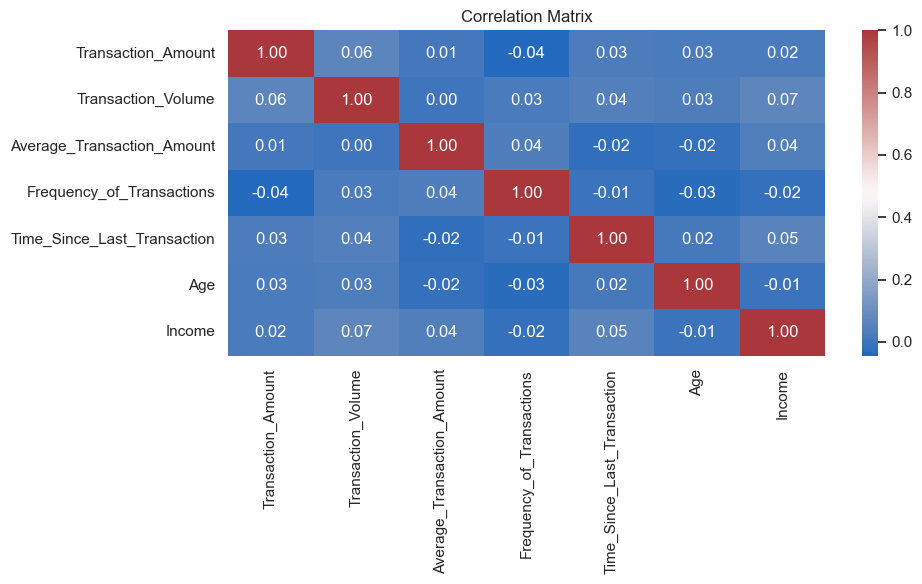

In [20]:
num_df = df.select_dtypes(include="number")
if len(num_df.columns) >= 2:
    Correlation_Matrix = num_df.corr()
    plt.figure(figsize=(10, 6))
    sns.heatmap(Correlation_Matrix, annot=True, cmap="vlag", fmt=".2f")
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation matrix.")

# Visualizations

Each section below auto-detects suitable columns from your data.
You can change the column names in each cell to explore different aspects.

## Bar_Chart

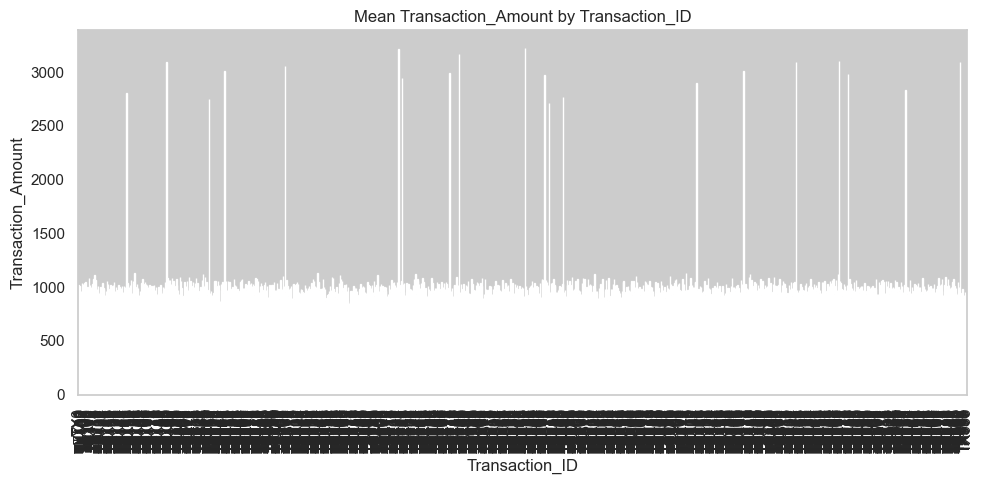

In [21]:
if categorical_cols and numeric_cols:
    grp = categorical_cols[0]  # Change to your column
    val = numeric_cols[0]      # Change to your column
    plt.figure(figsize=(10, 5))
    df.groupby(grp)[val].mean().plot(kind="bar", color=sns.color_palette("pastel"))
    plt.title(f"Mean {val} by {grp}")
    plt.xlabel(grp)
    plt.ylabel(val)
    plt.tight_layout()
    plt.show()
else:
    print("Need categorical + numeric columns for bar chart.")

## Line_Chart

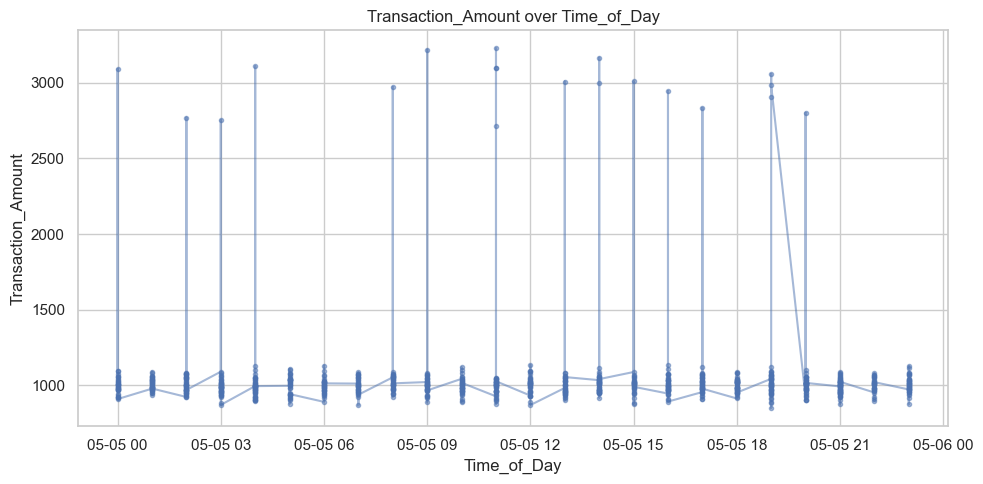

In [22]:
import warnings

date_cols = df.select_dtypes(include="datetime").columns.tolist()

if date_cols and numeric_cols:
    x_col = date_cols[0]      # Change to your column
    y_col = numeric_cols[0]   # Change to your column
    # Check if the date column has enough range for resampling
    date_range = df[x_col].max() - df[x_col].min()
    if date_range > pd.Timedelta(days=1):
        # Enough date range - use monthly resample
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=UserWarning)
            plt.figure(figsize=(10, 5))
            df.set_index(x_col).resample("ME").size().plot(figsize=(10, 5))
            plt.title(f"Trend Over Time")
            plt.ylabel("Count")
            plt.tight_layout()
            plt.show()
    else:
        # Date range too small - plot numeric values over time directly
        plt.figure(figsize=(10, 5))
        sorted_df = df.sort_values(by=x_col)
        plt.plot(sorted_df[x_col], sorted_df[y_col], marker="o", markersize=3, alpha=0.5)
        plt.title(f"{y_col} over {x_col}")
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.tight_layout()
        plt.show()
elif len(numeric_cols) >= 2:
    x_col = numeric_cols[0]
    y_col = numeric_cols[1]
    plt.figure(figsize=(10, 5))
    plt.plot(df[x_col], df[y_col], marker="o", markersize=3, alpha=0.5)
    plt.title(f"{y_col} vs {x_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()
else:
    print("Need date or numeric columns for line chart.")

## Histogram

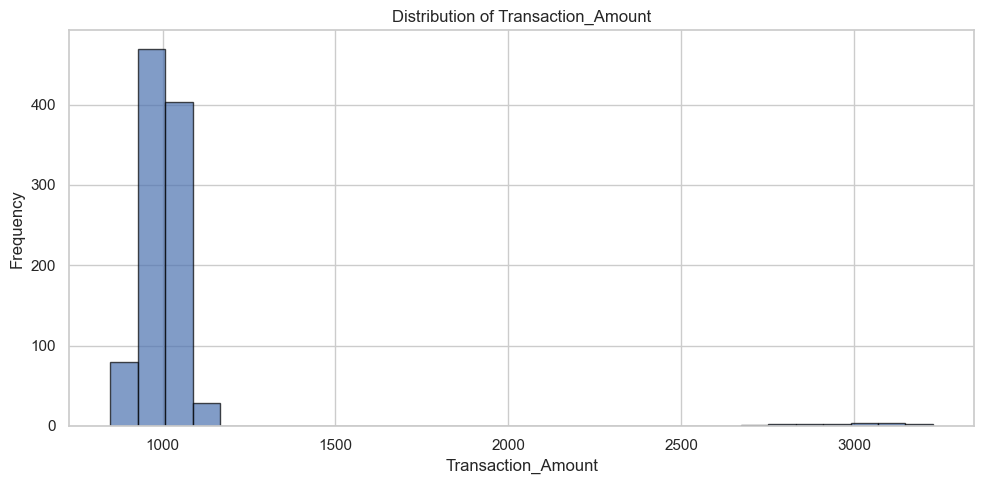

In [23]:
if numeric_cols:
    hist_col = numeric_cols[0]  # Change to your column
    plt.figure(figsize=(10, 5))
    plt.hist(df[hist_col].dropna(), bins=30, edgecolor="black", alpha=0.7)
    plt.title(f"Distribution of {hist_col}")
    plt.xlabel(hist_col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns for histogram.")

## Pie_Chart

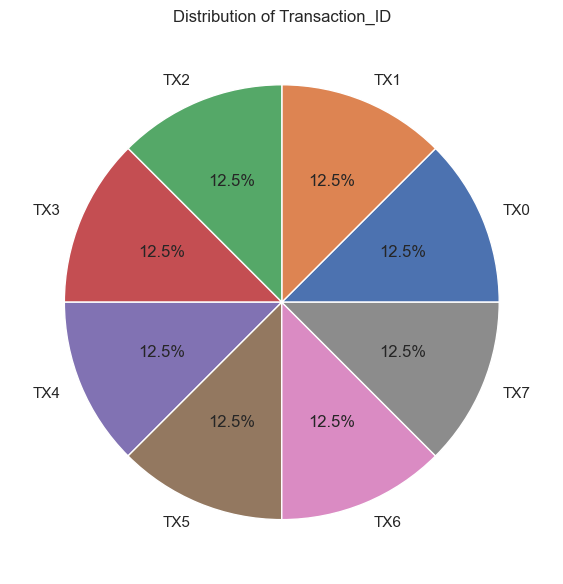

In [24]:
if categorical_cols:
    pie_col = categorical_cols[0]  # Change to your column
    df[pie_col].value_counts().head(8).plot.pie(autopct="%1.1f%%")
    plt.title(f"Distribution of {pie_col}")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns for pie chart.")

## Scatter_Plot

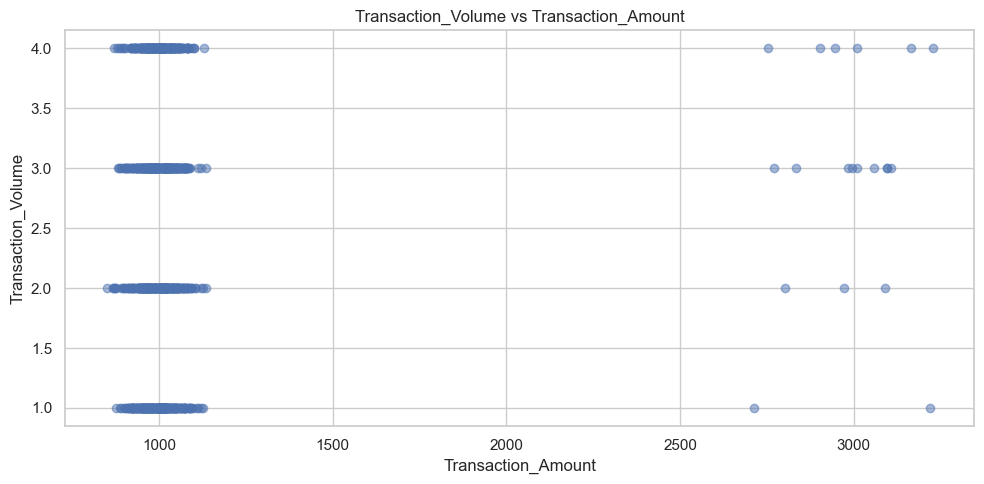

In [25]:
if len(numeric_cols) >= 2:
    x_col = numeric_cols[0]  # Change to your column
    y_col = numeric_cols[1]  # Change to your column
    plt.figure(figsize=(10, 5))
    plt.scatter(df[x_col], df[y_col], alpha=0.5)
    plt.title(f"{y_col} vs {x_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()
else:
    print("Need at least 2 numeric columns for scatter plot.")

## Box_Plot

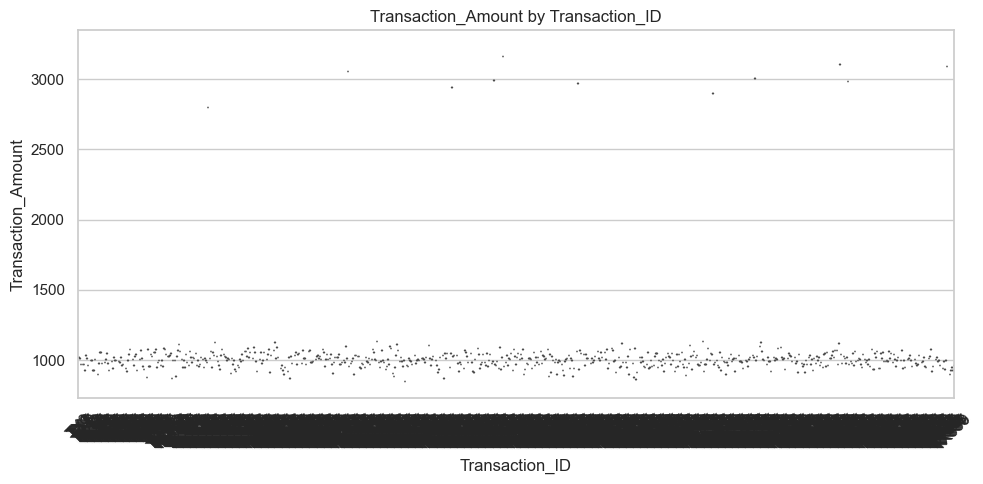

In [26]:
if numeric_cols:
    box_col = numeric_cols[0]  # Change to your column
    if categorical_cols:
        grp_col = categorical_cols[0]  # Change to your column
        plt.figure(figsize=(10, 5))
        sns.boxplot(x=grp_col, y=box_col, data=df)
        plt.title(f"{box_col} by {grp_col}")
        plt.xticks(rotation=45)
    else:
        plt.figure(figsize=(10, 5))
        sns.boxplot(y=df[box_col])
        plt.title(f"Box Plot of {box_col}")
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns for box plot.")

## Count_Plot

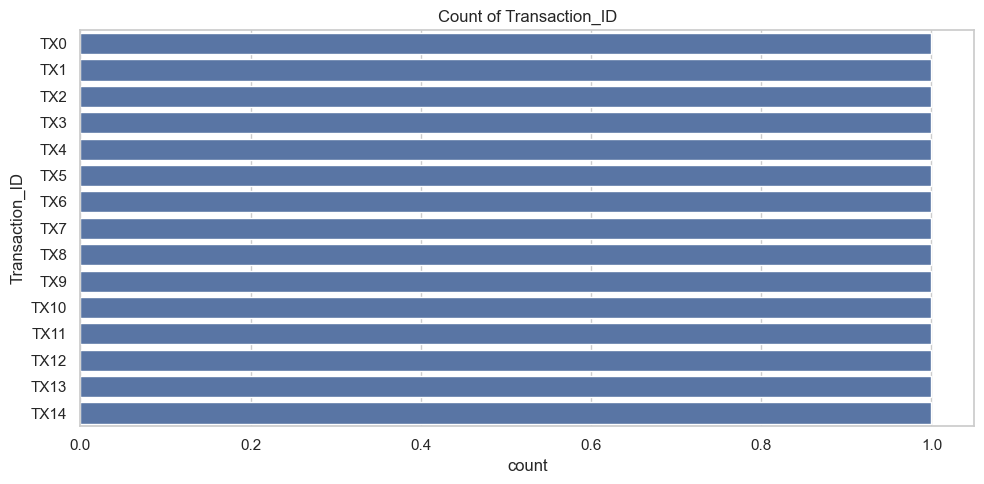

In [27]:
if categorical_cols:
    count_col = categorical_cols[0]  # Change to your column
    plt.figure(figsize=(10, 5))
    sns.countplot(y=count_col, data=df, order=df[count_col].value_counts().index[:15])
    plt.title(f"Count of {count_col}")
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns for count plot.")

# Export Cleaned Data
Save your cleaned dataset to a new file.

In [28]:
# Uncomment the line below to export
# df.to_csv("cleaned_data.csv", index=False)
# print(f"Exported at {datetime.now().strftime('%H:%M:%S')}")
print("Uncomment the lines above to export cleaned data.")

Uncomment the lines above to export cleaned data.
